In [2]:
import pandas as pd
import numpy as np
# Load feedback history from Notebook 12
feedback = pd.read_csv("../outputs/agent_feedback_history.csv")

# Load customer personas (state representation)
personas = pd.read_csv("../outputs/customer_personas.csv")

feedback.head()

,customer_unique_id,persona,agent_action,time_window,feedback_outcome,feedback_score,total_feedback_score,num_actions,num_positive,num_negative,num_churn
0,0000366f3b9a7992bf8c76cfdf3221e2,Silent Loyal Customers,No Action,W3,no_response,0.0,0.0,1,0,0,0
1,0000f6ccb0745a6a4b88665a16c9f078,High-Value Enthusiasts,No Action,W1,churned,-1.0,-1.0,1,0,0,1
2,00053a61a98854899e70ed204dd4bafe,High-Value Enthusiasts,No Action,W2,no_response,0.0,0.0,1,0,0,0
3,0005ef4cd20d2893f0d9fbd94d3c0d97,Silent Loyal Customers,No Action,W2,no_response,0.0,0.0,1,0,0,0
4,0006fdc98a402fceb4eb0ee528f6a8d4,Silent Loyal Customers,No Action,W1,no_response,0.0,0.0,1,0,0,0


In [3]:
reward_map = {
    "positive_response": 2,
    "no_response": 0,
    "negative_response": -1,
    "churned": -3
}

feedback["reward"] = feedback["feedback_outcome"].map(reward_map)

feedback[["agent_action", "feedback_outcome", "reward"]].head()

,agent_action,feedback_outcome,reward
0,No Action,no_response,0
1,No Action,churned,-3
2,No Action,no_response,0
3,No Action,no_response,0
4,No Action,no_response,0


In [4]:
feedback["reward"].value_counts().sort_index()

reward
-3     4263
-1     2662
 0    30269
 2     3885
Name: count, dtype: int64

In [5]:
cost_map = {
    "No Action": 0,
    "Loyalty Points + Feedback Request": 1,
    "Personalized Discount Offer": 2,
    "Win-Back Campaign": 3
}

feedback["action_cost"] = feedback["agent_action"].map(cost_map)
feedback[["agent_action", "action_cost"]].drop_duplicates()

,agent_action,action_cost
0,No Action,0
21,Personalized Discount Offer,2
38,Win-Back Campaign,3
178,Loyalty Points + Feedback Request,1


In [6]:
feedback["net_reward"] = feedback["reward"] - feedback["action_cost"]

feedback[
    ["agent_action", "feedback_outcome", "reward", "action_cost", "net_reward"]
].head()

,agent_action,feedback_outcome,reward,action_cost,net_reward
0,No Action,no_response,0,0,0
1,No Action,churned,-3,0,-3
2,No Action,no_response,0,0,0
3,No Action,no_response,0,0,0
4,No Action,no_response,0,0,0


In [7]:
persona_action_net_value = (
    feedback
    .groupby(["persona", "agent_action"])["net_reward"]
    .mean()
    .reset_index()
    .sort_values(by=["persona", "net_reward"], ascending=[True, False])
)

persona_action_net_value

,persona,agent_action,net_reward
0,Dissatisfied / Churn-Risk Customers,No Action,-0.276339
1,Dissatisfied / Churn-Risk Customers,Win-Back Campaign,-3.359649
2,Dormant / One-Time Buyers,No Action,-0.226590
3,Emerging Loyalists,No Action,-0.262122
4,Emerging Loyalists,Personalized Discount Offer,-1.732743
5,Fading Customers,No Action,-0.285714
6,Fading Customers,Win-Back Campaign,-3.378989
7,High-Value Enthusiasts,No Action,-0.259452
9,Silent Loyal Customers,No Action,-0.248800
8,Silent Loyal Customers,Loyalty Points + Feedback Request,-0.382353


In [8]:
learned_policy = (
    persona_action_net_value
    .groupby("persona")
    .first()
    .reset_index()
)

learned_policy.columns = ["persona", "best_action", "expected_net_reward"]
learned_policy


,persona,best_action,expected_net_reward
0,Dissatisfied / Churn-Risk Customers,No Action,-0.276339
1,Dormant / One-Time Buyers,No Action,-0.226590
2,Emerging Loyalists,No Action,-0.262122
3,Fading Customers,No Action,-0.285714
4,High-Value Enthusiasts,No Action,-0.259452
5,Silent Loyal Customers,No Action,-0.248800


In [9]:
learned_policy.to_csv(
    "../outputs/learned_cost_aware_agent_policy.csv",
    index=False
)

print("learned_cost_aware_agent_policy.csv saved")


learned_cost_aware_agent_policy.csv saved


In [10]:
original_actions = pd.read_csv("../outputs/agent_actions.csv")

policy_comparison = original_actions.merge(
    learned_policy,
    on="persona",
    how="left"
)

policy_comparison["policy_changed"] = (
    policy_comparison["agent_action"] 
    != policy_comparison["best_action"]
)

policy_comparison["policy_changed"].value_counts()


policy_changed
False    33067
True      6255
Name: count, dtype: int64

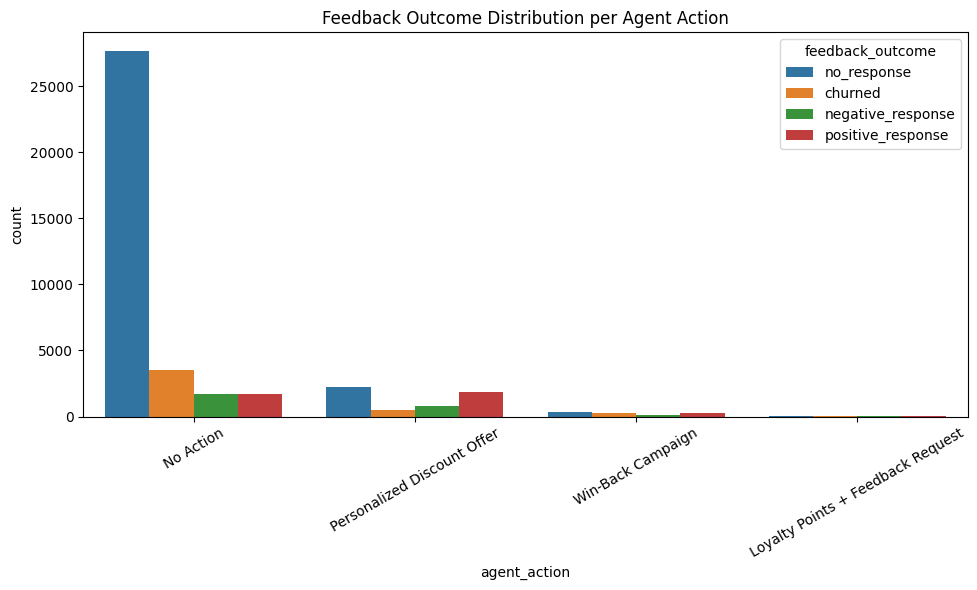

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.countplot(
    data=feedback,
    x="agent_action",
    hue="feedback_outcome"
)

plt.title("Feedback Outcome Distribution per Agent Action")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


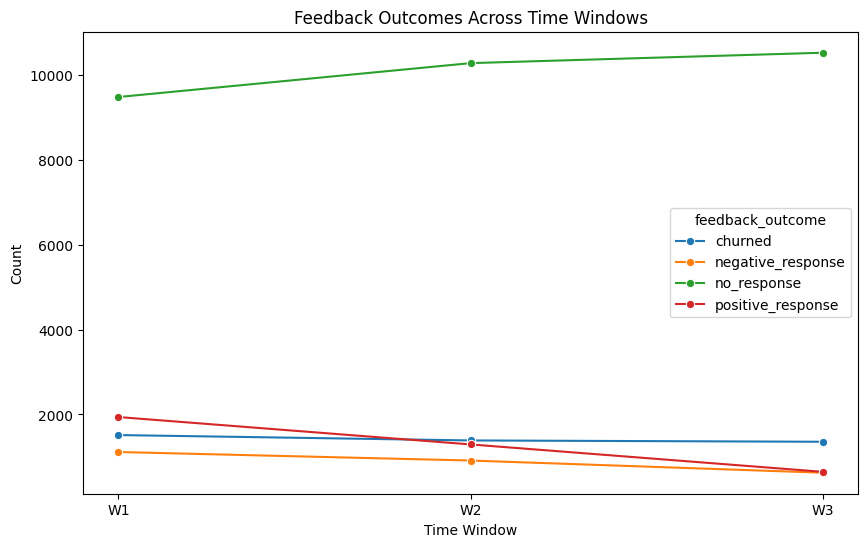

In [12]:
feedback_time = (
    feedback
    .groupby(["time_window", "feedback_outcome"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=feedback_time,
    x="time_window",
    y="count",
    hue="feedback_outcome",
    marker="o"
)

plt.title("Feedback Outcomes Across Time Windows")
plt.xlabel("Time Window")
plt.ylabel("Count")
plt.show()


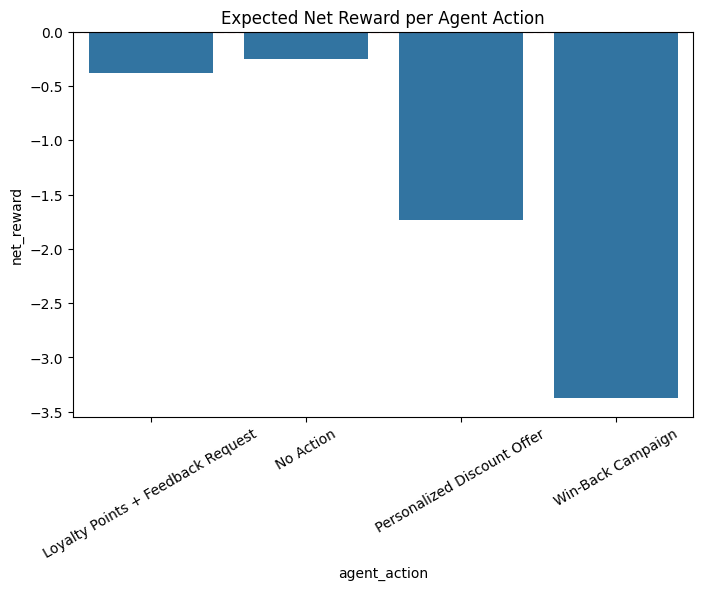

In [13]:
action_reward = (
    feedback
    .groupby("agent_action")["net_reward"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=action_reward,
    x="agent_action",
    y="net_reward"
)

plt.title("Expected Net Reward per Agent Action")
plt.xticks(rotation=30)
plt.axhline(0, color="red", linestyle="--")
plt.show()


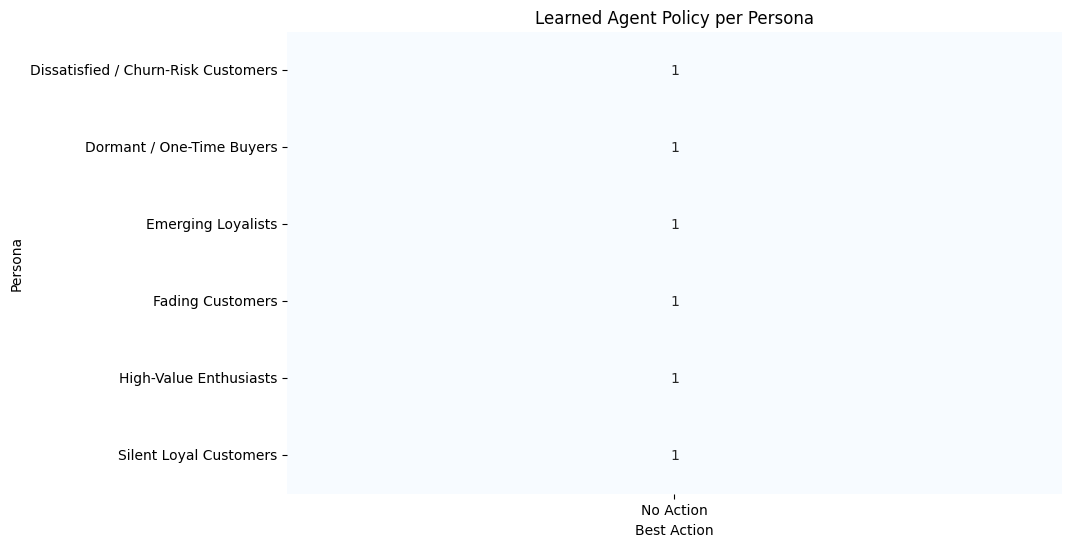

In [14]:
policy_matrix = learned_policy.copy()
policy_matrix["value"] = 1

policy_pivot = policy_matrix.pivot(
    index="persona",
    columns="best_action",
    values="value"
).fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(
    policy_pivot,
    annot=True,
    cmap="Blues",
    cbar=False
)

plt.title("Learned Agent Policy per Persona")
plt.xlabel("Best Action")
plt.ylabel("Persona")
plt.show()


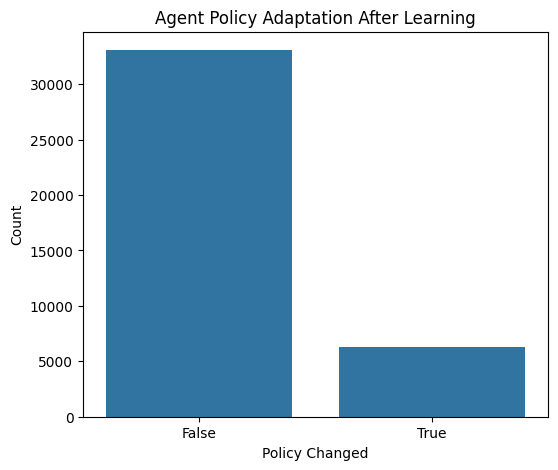

In [15]:
policy_change_counts = policy_comparison["policy_changed"].value_counts().reset_index()
policy_change_counts.columns = ["Policy Changed", "Count"]

plt.figure(figsize=(6,5))
sns.barplot(
    data=policy_change_counts,
    x="Policy Changed",
    y="Count"
)

plt.title("Agent Policy Adaptation After Learning")
plt.show()
